# FFB Pipeline v3 — steady-frame fusion and tarp-plane volume

Runs on CPU from the `ffb` package; the v1 and v2 notebooks are unchanged.

**Changes from v2**
- **Steady frames only.** Frames are kept from the start until the first frame where more than 8% of pixels moved over 2 cm or lost depth, versus the median of frames 0–7. The rule uses depth alone, never mass.
- **Frame reading.** Frames are copied (v2's reader stopped at 32 frames on split bags), and invalid pixels are kept out of the 3×3 median.
- **Volume.** Grid-free frustum volume above a RANSAC tarp plane. S5 also leaves combined-bag depth unaligned, so every bunch is measured on the same 848×480 depth grid.
- **Segmentation.** SAM 3 replaces Grounding DINO → SAM 2 → YOLO-World (runs only with transformers ≥ 5 and access to `facebook/sam3`).

**Status:** the steady-frame rule was added after the CPU run showed disturbed frames, so every v3 comparison here is exploratory until new bunches are recorded. Section 9 summarises the results.

In [1]:
import importlib.util
import os
import subprocess
import sys
import time
from pathlib import Path

ROOT = next((p for p in (Path.cwd(), Path.cwd().parent, Path("/kaggle/input/rgbd-mass-ffb")) if (p / "ffb").is_dir()), None)
assert ROOT is not None, "run from the repo or notebooks/ so the ffb package is importable"
sys.path.insert(0, str(ROOT))
if importlib.util.find_spec("pyrealsense2") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pyrealsense2"], check=True)

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ffb import experiment as ex
from ffb import io, volume
from ffb.fusion import FusionConfig, fuse

WORK = ROOT if os.access(ROOT, os.W_OK) else Path("/kaggle/working")
DATA, CACHE, OUT = ROOT / "data", WORK / "fused_cache", WORK / "results" / "v3"
OUT.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
GT = ex.ground_truth(ROOT)
BUNDLES = sorted(p for p in DATA.iterdir() if p.is_dir() and p.name.startswith("FFB"))
print("root:", ROOT)
print("bundles:", [p.name for p in BUNDLES])

root: D:\Work\RGBD-Mass
bundles: ['FFB10', 'FFB11', 'FFB12', 'FFB17', 'FFB18', 'FFB19', 'FFB31', 'FFB32', 'FFB33', 'FFB34', 'FFB35']


## 1. Configurations and run

S0 reproduces v2 exactly, and each later step adds one change. The comparisons of interest are S4 and S5 against S0 under v2's two calibration models (`per_session_k`, `global_k`). `aV+b` and `aV+bH` are exploratory.

In [2]:
FUSIONS = {
    "notebook": FusionConfig(reader="notebook", spatial="blur_then_mask"),
    "steady": FusionConfig(reader="fixed", spatial="blur_then_mask", frames="steady"),
    "steady_nanblur": FusionConfig(reader="fixed", spatial="mask_then_nanmedian", frames="steady"),
    "steady_native": FusionConfig(reader="native", spatial="mask_then_nanmedian", frames="steady"),
}
STEPS = [
    ("S0_notebook", "notebook", "V_grid"),
    ("S1_steady_frames", "steady", "V_grid"),
    ("S2_nan_blur", "steady_nanblur", "V_grid"),
    ("S3_frustum", "steady_nanblur", "V_frustum"),
    ("S4_tarp_plane", "steady_nanblur", "V_plane"),
    ("S5_unaligned_depth", "steady_native", "V_plane"),
]
t0 = time.time()
vol, keep = ex.run_bundles(DATA, FUSIONS, CACHE, keep_fusion="steady_native")
vol.to_csv(OUT / "volumes.csv", index=False)
print(f"done in {time.time() - t0:.0f}s")

FFB10  notebook        frames= 60/ 60 mask=depth  grid=  8.31L plane= 30.25L H= 27.0cm tilt= 2.4 0.8s


FFB10  steady          frames= 35/ 60 mask=depth  grid=  8.29L plane= 30.27L H= 27.0cm tilt= 2.5 0.7s


FFB10  steady_nanblur  frames= 35/ 60 mask=depth  grid=  8.28L plane= 30.33L H= 27.0cm tilt= 2.5 0.7s


FFB10  steady_native   frames= 35/ 60 mask=depth  grid=  5.27L plane= 26.95L H= 27.0cm tilt= 2.5 0.6s


FFB11  notebook        frames= 59/ 59 mask=depth  grid=  6.68L plane= 28.63L H= 24.6cm tilt= 2.4 0.7s


...

FFB35  notebook        frames= 32/ 32 mask=depth  grid=  5.68L plane= 14.61L H= 23.6cm tilt= 5.4 0.6s


FFB35  steady          frames= 83/120 mask=depth  grid=  5.68L plane= 14.60L H= 23.6cm tilt= 5.4 0.6s


FFB35  steady_nanblur  frames= 83/120 mask=depth  grid=  4.36L plane= 10.89L H= 23.6cm tilt= 5.4 0.5s


FFB35  steady_native   frames= 83/120 mask=depth  grid=  4.36L plane= 10.89L H= 23.6cm tilt= 5.4 0.6s


done in 93s


## 2. Which frames are steady

Share of pixels that changed relative to frames 0–7. The black line is the 8% cut-off; fusion uses only the frames before the first crossing.

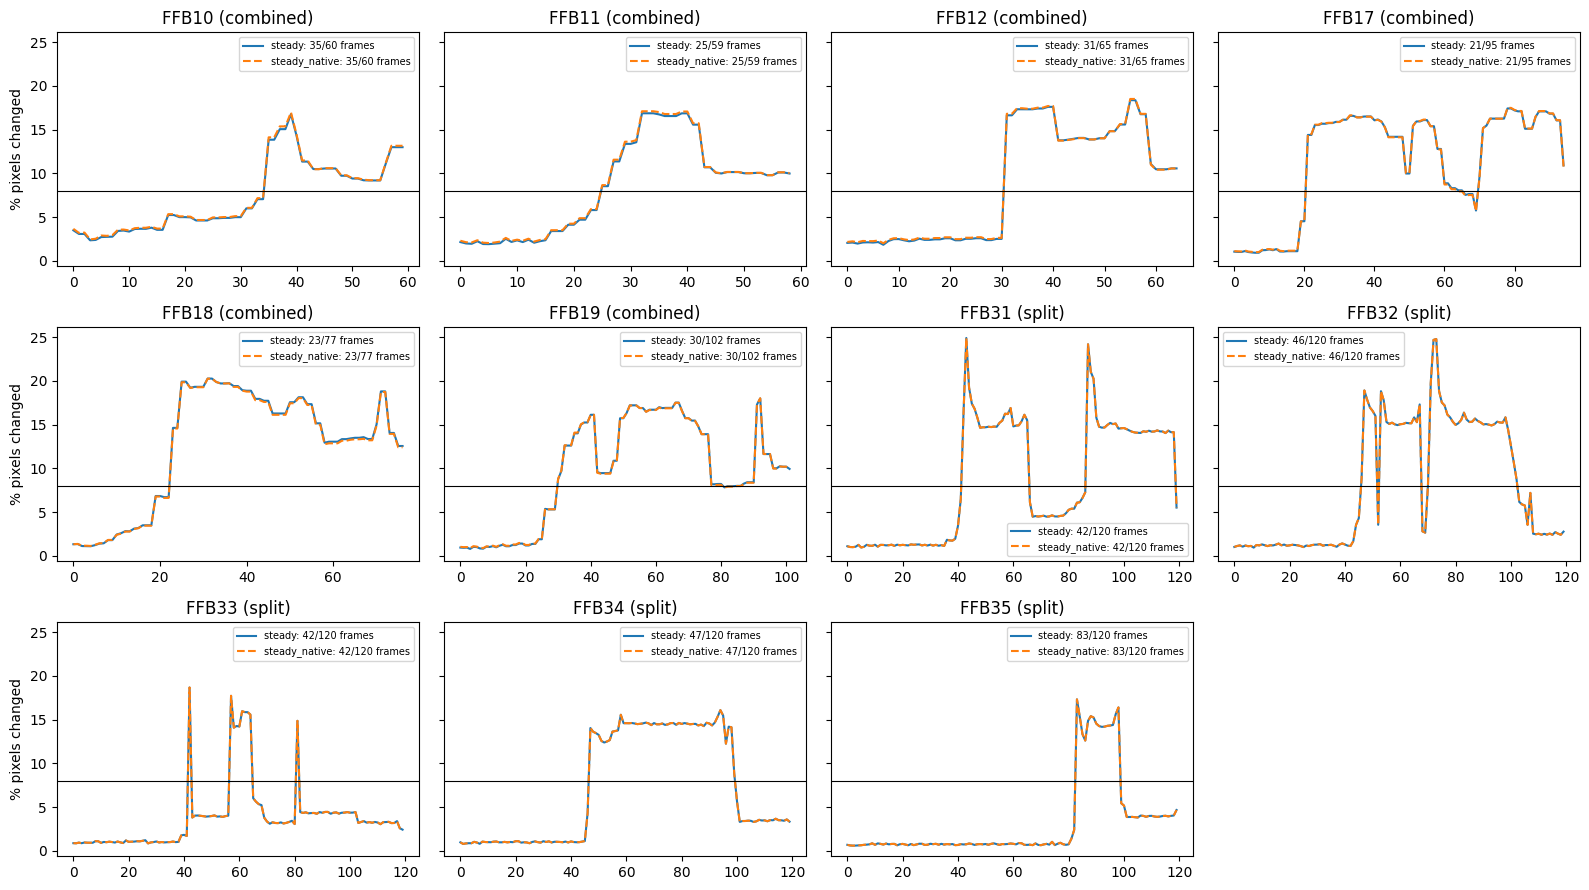

fusion  notebook  steady  steady_nanblur  steady_native
ffb                                                    
FFB10         60      35              35             35
FFB11         59      25              25             25
FFB12         65      31              31             31
FFB17         95      21              21             21
FFB18         77      23              23             23
FFB19        102      30              30             30
FFB31         32      42              42             42
FFB32         32      46              46             46
FFB33         32      42              42             42
FFB34         32      47              47             47
FFB35         32      83              83             83


In [3]:
fig, axes = plt.subplots(3, 4, figsize=(16, 9), sharey=True)
for ax, folder in zip(axes.flat, BUNDLES):
    b = io.find_bundle(str(folder))
    for name, style in (("steady", "-"), ("steady_native", "--")):
        cfg = FUSIONS[name]
        K = io.intrinsics(b, "depth" if cfg.reader == "native" else "auto")
        _, _, n_used, info = fuse(b, K, cfg, CACHE, return_info=True)
        ax.plot(100 * info["changed"], style, label=f"{name}: {n_used}/{info['n_read']} frames")
    ax.axhline(100 * FUSIONS["steady"].max_changed, color="k", lw=0.8)
    ax.set_title(f"{b.name} ({b.layout})")
    ax.legend(fontsize=7)
axes.flat[-1].axis("off")
for ax in axes[:, 0]:
    ax.set_ylabel("% pixels changed")
plt.tight_layout()
plt.savefig(OUT / "frame_stability.png", dpi=110)
plt.show()
print(vol.pivot_table(index="ffb", columns="fusion", values="n_frames").astype(int))

## 3. Parity with v2

The ratio of report.md litres to S0 litres should be constant within each recording layout, and the headline metrics should match v2.

In [4]:
REPORT_A_L = {"FFB10": 18.70, "FFB11": 15.01, "FFB12": 22.56, "FFB17": 11.53, "FFB18": 13.19, "FFB19": 18.61,
              "FFB31": 13.24, "FFB32": 7.95, "FFB33": 14.90, "FFB34": 12.17, "FFB35": 14.38}
par = ex.parity(ex.step_frame(vol, GT, "notebook", "V_grid"), REPORT_A_L)
print(pd.DataFrame(par["ratio_by_group"]).round(4).to_string(index=False))
for key in ("insample_per_session", "cv_global"):
    print(key, {k: round(v, 3) if isinstance(v, float) else v for k, v in par[key].items()})

   group  count   mean    std  cv_pct
combined      6 2.2488 0.0004  0.0188
   split      5 2.5304 0.0007  0.0271
insample_per_session {'n': 10, 'mae': 1.273, 'mape': 9.755, 'pearson_r2': 0.857, 'r2': 0.81}
cv_global {'model': 'global_k', 'n_pred': 2100, 'n_missing': 0, 'mae': 1.659, 'mape': 12.316, 'pearson_r2_all': 0.86, 'r2_all': 0.696, 'pearson_r2_per_ffb': 0.886}


## 4. Leave-one-out results (n = 10, FFB18 excluded)

`mae_lo`/`mae_hi` give the 95% bootstrap CI. `vs_S0_*` is the paired difference in absolute error against v2 (negative means better).

In [5]:
lad, preds = ex.ladder(vol, GT, STEPS)
lad.to_csv(OUT / "ladder.csv", index=False)
cols = ["step", "model", "mae", "mae_lo", "mae_hi", "mape", "pearson_r2", "r2", "vs_S0_diff", "vs_S0_lo", "vs_S0_hi"]
print("Calibration models used by v2:")
print(lad[lad["primary"]][cols].round(2).to_string(index=False))
print("\nExploratory models:")
print(lad[~lad["primary"]][cols].round(2).to_string(index=False))

Calibration models used by v2:
              step         model  mae  mae_lo  mae_hi  mape  pearson_r2    r2  vs_S0_diff  vs_S0_lo  vs_S0_hi
       S0_notebook per_session_k 1.65    1.24    2.10 12.35        0.81  0.73         NaN       NaN       NaN
       S0_notebook      global_k 1.60    1.16    2.01 11.83        0.89  0.74         NaN       NaN       NaN
  S1_steady_frames per_session_k 1.58    1.14    2.07 11.70        0.77  0.74       -0.07     -0.48      0.20
  S1_steady_frames      global_k 1.43    0.93    1.93 10.81        0.84  0.77       -0.17     -0.48      0.07
       S2_nan_blur per_session_k 2.29    1.34    3.32 17.46        0.65  0.34        0.64     -0.19      1.45
       S2_nan_blur      global_k 2.28    1.12    3.58 18.43        0.80  0.22        0.68     -0.47      1.96
        S3_frustum per_session_k 2.44    1.34    3.61 18.44        0.61  0.21        0.79     -0.18      1.74
        S3_frustum      global_k 5.84    4.31    7.58 39.63        0.00 -2.47        4.24

## 5. Geometry checks

A top view of an ellipsoid resting on a plane should give about 1.33× its true volume. Heights above the fitted tarp should track the caliper thickness.

In [6]:
v = vol.dropna(subset=["V_plane"]).copy()
v["plane_over_true"] = 1000 * v["V_plane"] / GT.loc[v["ffb"], "Actual_Volume_L"].to_numpy()
v["H_minus_T_cm"] = 100 * v["H"] - GT.loc[v["ffb"], "Thickness_cm"].to_numpy()
print(v[v["ffb"] != "FFB18"].groupby(["fusion", "layout"])[["plane_over_true", "H_minus_T_cm", "tilt_deg", "plane_rmse_mm"]]
      .agg(["mean", "std"]).round(2))
for name in FUSIONS:
    s = v[v["fusion"] == name]
    print(f"{name:15s} corr(H, caliper thickness) = {np.corrcoef(s['H'], GT.loc[s['ffb'], 'Thickness_cm'])[0, 1]:.3f}")
tarp = float(v.loc[v["fusion"] == "steady_native", "tarp_depth"].median())
cams = {"848x480": keep["FFB31"][0], "1280x720": io.intrinsics(io.find_bundle(str(DATA / "FFB10")), "auto")}
print(pd.DataFrame(ex.synthetic_check(tarp, cams)).round(3).to_string(index=False))

                        plane_over_true       H_minus_T_cm       tilt_deg       plane_rmse_mm      
                                   mean   std         mean   std     mean   std          mean   std
fusion         layout                                                                              
notebook       combined            1.75  0.20         2.38  1.11     3.65  1.64          3.97  0.71
               split               1.18  0.19         0.34  1.33     4.34  0.95          3.83  0.12
steady         combined            1.78  0.19         1.99  0.85     3.79  1.72          3.87  0.69
               split               1.18  0.18         0.34  1.33     4.34  0.95          3.82  0.13
steady_nanblur combined            1.78  0.19         2.00  0.84     3.77  1.72          3.80  0.67
               split               1.07  0.19         0.34  1.38     4.34  0.99          3.81  0.26
steady_native  combined            1.58  0.20         1.98  0.85     3.81  1.78          3.84  0.63


depth_grid             shape  tarp_m  ref_over_true  frustum_over_ref  grid_plane_ref_over_ref  grid_tight_mask_over_ref
   848x480              dome   1.552          1.000             1.000                    0.331                     0.190
   848x480 resting ellipsoid   1.552          1.328             0.999                    0.359                     0.085
  1280x720              dome   1.552          1.000             1.000                    0.739                     0.428
  1280x720 resting ellipsoid   1.552          1.328             1.000                    0.803                     0.190


Does a wrinkled tarp explain the session gap? For the steady, unaligned fusion, this checks how much of the tarp next to each bunch rises above the fitted plane, and how much of the volume comes from mask pixels under 4 cm tall.

In [7]:
disk = lambda r: cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * r + 1, 2 * r + 1))
layout = dict(zip(vol["ffb"], vol["layout"]))
rows = []
for ffb, (K, mask, rgb, fused) in keep.items():
    n, d, _ = volume.fit_plane(volume.tarp_points(fused, mask, K))
    m8 = mask.astype(np.uint8)
    near = cv2.dilate(m8, disk(55)).astype(bool) & ~cv2.dilate(m8, disk(15)).astype(bool)
    h_near = volume.project(fused, near, K).astype(float) @ n + d
    valid = mask & (fused > 0)
    h = volume.project(fused, mask, K).astype(float) @ n + d
    zp = volume.plane_depth((n, d), K, fused.shape)[valid]
    dv = np.clip(np.nan_to_num(zp ** 3 - fused[valid].astype(float) ** 3), 0, None)
    rows.append(dict(ffb=ffb, layout=layout[ffb], near_tarp_above_2cm_pct=100 * (h_near > 0.02).mean(),
                     near_tarp_p90_cm=100 * np.percentile(h_near, 90), volume_below_4cm_pct=100 * dv[h < 0.04].sum() / dv.sum()))
folds = pd.DataFrame(rows).set_index("ffb")
print(folds.round(2).to_string())
print(folds.drop(index=ex.EXCLUDED).groupby("layout").mean(numeric_only=True).round(2).to_string())

         layout  near_tarp_above_2cm_pct  near_tarp_p90_cm  volume_below_4cm_pct
ffb                                                                             
FFB10  combined                     1.93              0.50                  0.00
FFB11  combined                     2.18              1.25                  0.00
FFB12  combined                     6.75              1.66                  0.01
FFB17  combined                     2.16              0.59                  0.47
FFB18  combined                     0.01              0.57                  1.27
FFB19  combined                     2.09              0.69                  0.48
FFB31     split                    11.75              5.14                  1.36
FFB32     split                     1.97              0.62                  0.00
FFB33     split                    10.16              2.17                  0.00
FFB34     split                     6.65              0.78                  0.66
FFB35     split             

## 6. Prediction intervals, cross-validation and caliper baseline

In [8]:
chosen = [STEPS[0], STEPS[1], STEPS[4], STEPS[5]]
print(pd.DataFrame(ex.intervals(vol, GT, chosen)).round(2).to_string(index=False))
cv = [dict(step=s) | ex.cv_summary(ex.step_frame(vol, GT, f, c), m) for s, f, c in chosen for m in ex.BASE_MODELS[:2]]
print(pd.DataFrame(cv).round(3).to_string(index=False))
ffbs = [f for f in ex.step_frame(vol, GT, "notebook", "V_grid").index if f not in ex.EXCLUDED]
for k, m in ex.caliper(GT, ffbs).items():
    print("caliper ellipsoid", k, {kk: round(vv, 3) for kk, vv in m.items()})

              step         model  coverage  median_width_kg
       S0_notebook per_session_k       0.9             6.19
       S0_notebook      global_k       0.9             5.60
  S1_steady_frames per_session_k       0.9             6.25
  S1_steady_frames      global_k       0.9             5.88
     S4_tarp_plane per_session_k       0.9             7.86
     S4_tarp_plane      global_k       0.9            13.17
S5_unaligned_depth per_session_k       0.9             7.82
S5_unaligned_depth      global_k       0.9            11.90


              step         model  n_pred  n_missing   mae   mape  pearson_r2_all  r2_all  pearson_r2_per_ffb
       S0_notebook per_session_k    2000        100 1.970 14.360           0.676   0.541               0.770
       S0_notebook      global_k    2100          0 1.659 12.316           0.860   0.696               0.886
  S1_steady_frames per_session_k    2000        100 2.211 15.474           0.497   0.361               0.673
  S1_steady_frames      global_k    2100          0 1.787 13.039           0.771   0.616               0.842
     S4_tarp_plane per_session_k    2000        100 2.055 14.781           0.569   0.483               0.662
     S4_tarp_plane      global_k    2100          0 3.464 24.851           0.675  -0.372               0.724
S5_unaligned_depth per_session_k    2000        100 2.110 15.090           0.574   0.453               0.659
S5_unaligned_depth      global_k    2100          0 2.847 20.011           0.707  -0.013               0.749
caliper ellipsoid l

       actual_kg  S0_notebook:per_session_k  S0_notebook:global_k  S1_steady_frames:per_session_k  S1_steady_frames:global_k  S4_tarp_plane:per_session_k  S4_tarp_plane:global_k  S5_unaligned_depth:per_session_k  S5_unaligned_depth:global_k
ffb                                                                                                                                                                                                                                             
FFB10       17.0                      18.74                 19.22                           18.94                      19.34                        16.79                   18.71                             16.58                        18.22
FFB11       14.0                      14.86                 15.28                           14.94                      15.31                        16.30                   18.00                             17.05                        18.52
FFB12       21.6                    

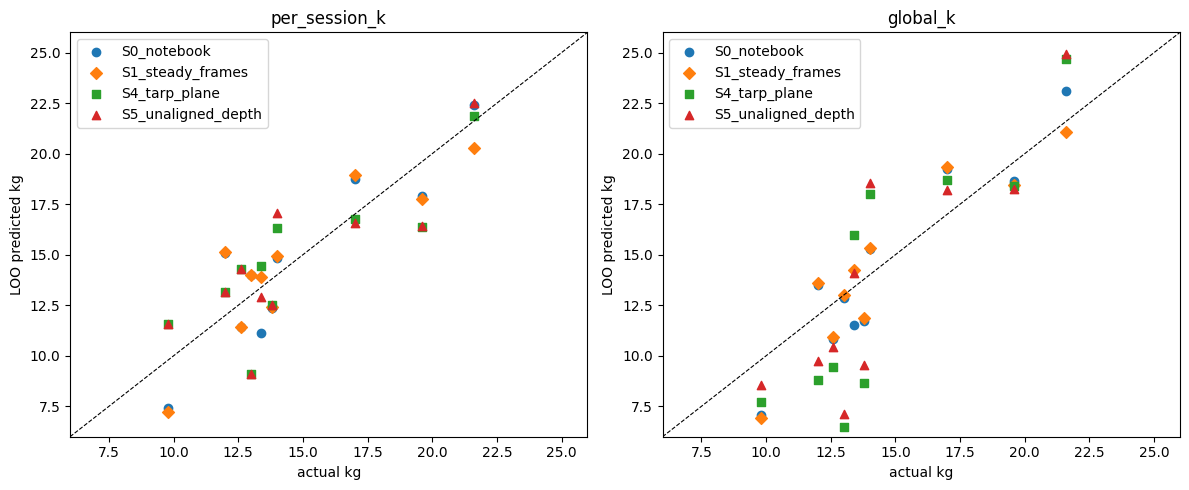

In [9]:
per = pd.DataFrame({"actual_kg": GT.loc[preds[("S0_notebook", "global_k")].index, "Actual_Mass_kg"]})
shown = ("S0_notebook", "S1_steady_frames", "S4_tarp_plane", "S5_unaligned_depth")
for (step, model), p in preds.items():
    if step in shown and model in ex.PRIMARY_MODELS:
        per[f"{step}:{model}"] = p
print(per.round(2).to_string())
per.round(3).to_csv(OUT / "per_ffb_loo.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, model in zip(axes, ex.PRIMARY_MODELS):
    for step, marker in zip(shown, "oDs^"):
        ax.scatter(per["actual_kg"], per[f"{step}:{model}"], marker=marker, label=step)
    ax.plot([6, 26], [6, 26], "k--", lw=0.8)
    ax.set(xlim=(6, 26), ylim=(6, 26), xlabel="actual kg", ylabel="LOO predicted kg", title=model)
    ax.legend()
plt.tight_layout()
plt.savefig(OUT / "loo_scatter.png", dpi=110)
plt.show()

## 7. Held-out comparison with v2

Every step against S0 under leave-one-out, all 330 splits of 4 train / 7 test, and all 330 splits of 7 train / 4 test. As in v2, FFB18 is used for training in the split schemes but never scored. Each cell is MAE in kg, followed by the paired per-bunch difference from S0 and its 95% bootstrap CI (negative means better than v2).

In [10]:
cmp = ex.heldout_comparison(vol, GT, STEPS)
cmp.to_csv(OUT / "heldout_comparison.csv", index=False)
order = [s for s, _, _ in STEPS]
for model in [m.name for m in ex.BASE_MODELS]:
    s = cmp[cmp["model"] == model].copy()
    s["cell"] = [f"{r.mae:.2f}" if pd.isna(r.vs_first_diff) else f"{r.mae:.2f} ({r.vs_first_diff:+.2f} [{r.vs_first_lo:+.2f}, {r.vs_first_hi:+.2f}])"
                 for r in s.itertuples()]
    print(f"\n{model}")
    print(s.pivot(index="step", columns="scheme", values="cell").reindex(order)[["LOO", "4/7", "7/4"]].to_string())
d = cmp.dropna(subset=["vs_first_diff"])
print(f"\nsignificantly better than v2: {int((d['vs_first_hi'] < 0).sum())} of {len(d)}; significantly worse: {int((d['vs_first_lo'] > 0).sum())}")


per_session_k
scheme                                      LOO                          4/7                          7/4
step                                                                                                     
S0_notebook                                1.65                         1.97                         1.65
S1_steady_frames    1.58 (-0.07 [-0.48, +0.20])  2.21 (+0.24 [-0.21, +0.66])  1.85 (+0.20 [-0.37, +0.80])
S2_nan_blur         2.29 (+0.64 [-0.19, +1.45])  3.35 (+1.37 [+0.46, +2.39])  2.69 (+1.04 [+0.13, +1.92])
S3_frustum          2.44 (+0.79 [-0.18, +1.74])  3.76 (+1.78 [+0.79, +2.90])  2.98 (+1.33 [+0.37, +2.29])
S4_tarp_plane       1.69 (+0.04 [-0.82, +0.97])  2.06 (+0.09 [-0.60, +0.79])  1.81 (+0.15 [-0.65, +1.01])
S5_unaligned_depth  1.78 (+0.13 [-0.80, +1.12])  2.11 (+0.14 [-0.65, +0.95])  1.86 (+0.20 [-0.72, +1.18])

global_k
scheme                                      LOO                          4/7                          7/4
step                 

## 8. SAM 3 segmentation

Uses the steady, unaligned fusion: a text prompt alone, then text plus the depth-mask box as a positive exemplar.

In [11]:
sam = ex.sam3_eval(keep)
print(sam["status"])
if sam["status"] == "ok":
    print(pd.DataFrame(sam["rows"]).round(3).to_string(index=False))

blocked: RuntimeError: SAM 3 needs transformers>=5 with Sam3Model


## 9. Results (exploratory, n = 10)

**Parity.** S0 matches v2: report ÷ S0 litres is constant to within 0.03% in each session, in-sample MAE is 1.27 kg, and 4/7 CV gives MAE 1.66 kg with per-bunch r² 0.886.

**Held-out MAE (kg).** Leave-one-out, and all 330 splits of 4 train / 7 test and of 7 train / 4 test.

| Step | One gain: LOO | 4/7 | 7/4 | Per-session: LOO | 4/7 | 7/4 |
|---|---|---|---|---|---|---|
| S0 v2 | **1.60** | **1.66** | **1.59** | **1.65** | **1.97** | **1.65** |
| S1 steady frames | 1.43 | 1.79 | 1.58 | 1.58 | 2.21 | 1.85 |
| S2 + NaN-aware blur | 2.28 | 2.72 | 2.50 | 2.29 | 3.35 | 2.69 |
| S3 + frustum volume | 5.84 | 5.80 | 5.78 | 2.44 | 3.76 | 2.98 |
| S4 + tarp plane | 3.26 | 3.46 | 3.29 | 1.69 | 2.06 | 1.81 |
| S5 + unaligned depth | 2.69 | 2.85 | 2.70 | 1.78 | 2.11 | 1.86 |

For comparison, the caliper ellipsoid fitted on the other 40 bunches scores 1.67 kg.

**Takeaways**
- **No change beats v2.** Across the three schemes and four calibration models, none of 60 paired comparisons is significantly better than v2 and 25 are significantly worse.
- **v2 with one gain is the most stable result** (1.59–1.66 kg), level with the caliper baseline. Its per-session gains degrade to 1.97 kg with only 4 training bunches.
- **Steady frames do not improve accuracy.** Against v2 with one gain they differ by −0.17, +0.13 and −0.01 kg (LOO, 4/7, 7/4), all within noise. They remain a data-quality step.
- **The tarp-plane volume ties v2 with per-session gains** (+0.04 to +0.15 kg) but fails with one gain. Volume above the plane ÷ true volume is 1.58 in session 1 and 1.07 in session 2 (unaligned depth), a gap one gain cannot absorb. Its geometry is sound: height above the tarp vs caliper thickness gives r = 0.87.
- **v2's grid volume copes with one gain by accident.** Two of its errors offset between sessions: empty grid cells at 848×480, and a reference depth above the tarp for tight masks.
- **Tarp folds do not explain the gap.** The tarp beside the bunch is flatter in session 1. Leading untested explanation: session 1 bunches measure about 2 cm taller than their caliper thickness, against 0.3 cm in session 2.
- **Exploratory lead:** v2 volume plus object height (mass = a·V + b·H) scores 1.04 kg (LOO), 1.17 kg (7/4) and 1.65 kg (4/7). It needs about 7 training bunches and was chosen after seeing the data.
- **SAM 3 did not run:** it needs transformers ≥ 5 and approved access to `facebook/sam3`.